## <CENTER> MASKED ENCODER 

# 1. ENVIRONMENT SETUP 

In [51]:
!pip install timm einops gradio --quiet

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from tqdm import tqdm
import math

# 2. MODEL ARCHITECTURE

In [72]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image / Patch settings
IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196 patches

VISIBLE_PATCH_RATIO = 0.25
VISIBLE_PATCHES = int(NUM_PATCHES * VISIBLE_PATCH_RATIO)  # 49
MASKED_PATCHES = NUM_PATCHES - VISIBLE_PATCHES            # 147

# Encoder (ViT Base)
ENCODER_DIM = 768
ENCODER_LAYERS = 12
ENCODER_HEADS = 12

# Decoder (ViT Small)
DECODER_DIM = 384
DECODER_LAYERS = 12
DECODER_HEADS = 6

# Training
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 0.05

## loading dataset

In [54]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

dataset = ImageFolder(
    root="/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train",
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("Dataset size:", len(dataset))

Dataset size: 100000


## patching 
Split 224×224 image → 16×16 patches (196 patches)

In [55]:
def patchify(images, patch_size=16):
    """
    images: (B,3,224,224)
    returns: (B,196,768)
    """

    patches = rearrange(
        images,
        'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
        p1=patch_size,
        p2=patch_size
    )

    return patches

In [56]:
def random_masking(x, mask_ratio=0.75):
    """
    x: (B, N, D)
    B = batch
    N = number of patches (196)
    D = patch dimension
    """

    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))  # 49 (25%)

    noise = torch.rand(B, N, device=x.device)

    # shuffle patches
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # keep first subset
    ids_keep = ids_shuffle[:, :len_keep]

    x_visible = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1,1,D)
    )

    # create mask
    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0

    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore

In [57]:
def unpatchify(patches, patch_size=16):
    """
    patches: (B,196,768)
    returns: (B,3,224,224)
    """

    h = w = int(patches.shape[1] ** 0.5)

    images = rearrange(
        patches,
        'b (h w) (p1 p2 c) -> b c (h p1) (w p2)',
        h=h,
        p1=patch_size,
        p2=patch_size,
        c=3
    )

    return images

## patch embeding layer

In [58]:
class PatchEmbed(nn.Module):
    
    def __init__(self, patch_dim=768, embed_dim=768):
        super().__init__()
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        return self.proj(x)

## tranformer encoder block

In [59]:
class TransformerBlock(nn.Module):

    def __init__(self, dim, heads):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):

        x = x + self.attn(
            self.norm1(x),
            self.norm1(x),
            self.norm1(x)
        )[0]

        x = x + self.mlp(self.norm2(x))

        return x

## positional embeding + mask token

In [60]:
class MAEEmbeddings(nn.Module):

    def __init__(self, num_patches=196, enc_dim=768, dec_dim=384):
        super().__init__()

        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches, enc_dim)
        )

        self.mask_token = nn.Parameter(
            torch.randn(1,1,dec_dim)
        )

    def forward(self):
        return self.pos_embed

# MAE MODEL

## ViT Encoder

In [61]:
class ViTEncoder(nn.Module):

    def __init__(self, dim=768, depth=12, heads=12):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerBlock(dim, heads) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):

        for layer in self.layers:
            x = layer(x)

        return self.norm(x)

## vit decoder

In [62]:
class ViTDecoder(nn.Module):

    def __init__(self, dim=384, depth=12, heads=6):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerBlock(dim, heads) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):

        for layer in self.layers:
            x = layer(x)

        return self.norm(x)

## MAE model initializatin

In [63]:
class MaskedAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbed()

        # Encoder positional embedding
        self.pos_embed = nn.Parameter(
            torch.randn(1, NUM_PATCHES, ENCODER_DIM)
        )

        # Encoder
        self.encoder = ViTEncoder(
            ENCODER_DIM,
            ENCODER_LAYERS,
            ENCODER_HEADS
        )

        # Projection to decoder dimension
        self.enc_to_dec = nn.Linear(
            ENCODER_DIM,
            DECODER_DIM
        )

        # Mask token
        self.mask_token = nn.Parameter(
            torch.randn(1,1,DECODER_DIM)
        )

        # Decoder positional embedding
        self.decoder_pos_embed = nn.Parameter(
            torch.randn(1, NUM_PATCHES, DECODER_DIM)
        )

        # Decoder
        self.decoder = ViTDecoder(
            DECODER_DIM,
            DECODER_LAYERS,
            DECODER_HEADS
        )

        # Reconstruction head
        self.head = nn.Linear(
            DECODER_DIM,
            PATCH_SIZE*PATCH_SIZE*3
        )

    def forward(self, images):

        # 1️⃣ Patchify
        patches = patchify(images)

        # 2️⃣ Patch embedding
        x = self.patch_embed(patches)

        # 3️⃣ Add encoder positional embedding
        x = x + self.pos_embed

        # 4️⃣ Random masking
        x_visible, mask, ids_restore = random_masking(x)

        # 5️⃣ Encoder
        latent = self.encoder(x_visible)

        # 6️⃣ Project encoder output → decoder dim
        x = self.enc_to_dec(latent)

        B, N, D = x.shape

        # 7️⃣ Create mask tokens
        mask_tokens = self.mask_token.repeat(
            B,
            NUM_PATCHES - N,
            1
        )

        # 8️⃣ Concatenate visible + mask tokens
        x_ = torch.cat([x, mask_tokens], dim=1)

        # 9️⃣ Restore original order
        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1,1,D)
        )

        # 🔟 Add decoder positional embedding
        x_ = x_ + self.decoder_pos_embed

        # 11️⃣ Decoder
        x_ = self.decoder(x_)

        # 12️⃣ Reconstruct patches
        pred = self.head(x_)

        return pred, mask

In [64]:
model = MaskedAutoencoder().to(device)

print("Model Loaded")

Model Loaded


# 3. Training 

## mae loss

In [65]:
def mae_loss(pred, target, mask):
    """
    pred: predicted patches (B,196,768)
    target: ground truth patches (B,196,768)
    mask: (B,196)  1=masked 0=visible
    """

    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)  # patch-wise MSE

    loss = (loss * mask).sum() / mask.sum()

    return loss

## optimizer (ADAMW)

In [66]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [67]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [68]:
scaler = torch.amp.GradScaler("cuda")

In [73]:
loss_history = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for images, _ in tqdm(dataloader):

        images = images.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            pred, mask = model(images)

            target = patchify(images)

            loss = mae_loss(pred, target, mask)

        scaler.scale(loss).backward()

        # optional gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    scheduler.step()

    avg_loss = total_loss / len(dataloader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.4f}")

100%|██████████| 3125/3125 [13:40<00:00,  3.81it/s]


Epoch 1/5  Loss: 0.0299


100%|██████████| 3125/3125 [13:57<00:00,  3.73it/s] 


Epoch 2/5  Loss: 0.0299


100%|██████████| 3125/3125 [13:39<00:00,  3.81it/s]


Epoch 3/5  Loss: 0.0300


100%|██████████| 3125/3125 [13:39<00:00,  3.81it/s]


Epoch 4/5  Loss: 0.0300


100%|██████████| 3125/3125 [13:39<00:00,  3.81it/s]

Epoch 5/5  Loss: 0.0300


# 4. VISUALIZATION

### apply masking

In [74]:
def apply_mask(images, mask):

    patches = patchify(images)

    mask = mask.unsqueeze(-1)

    masked_patches = patches * (1 - mask)

    masked_images = unpatchify(masked_patches)

    return masked_images

### reconstruct

In [75]:
def reconstruct_images(model, images):

    model.eval()

    with torch.no_grad():

        pred, mask = model(images)

        recon_images = unpatchify(pred)

        masked_images = apply_mask(images, mask)

    return masked_images, recon_images

In [76]:
def show_reconstruction(original, masked, reconstructed, n=5):

    original = original.cpu()
    masked = masked.cpu()
    reconstructed = reconstructed.cpu()

    plt.figure(figsize=(10,6))

    for i in range(n):

        # masked
        plt.subplot(3, n, i+1)
        plt.imshow(masked[i].permute(1,2,0))
        plt.axis("off")
        if i==0:
            plt.title("Masked Input")

        # reconstructed
        plt.subplot(3, n, i+n+1)
        plt.imshow(reconstructed[i].permute(1,2,0))
        plt.axis("off")
        if i==0:
            plt.title("Reconstruction")

        # original
        plt.subplot(3, n, i+2*n+1)
        plt.imshow(original[i].permute(1,2,0))
        plt.axis("off")
        if i==0:
            plt.title("Original")

    plt.tight_layout()
    plt.show()

In [77]:
images, _ = next(iter(dataloader))

images = images[:5].to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.081181295..0.89771926].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15053658..1.1757126].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08938682..0.94032717].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.029955622..1.2557669].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.034786575..1.0693307].


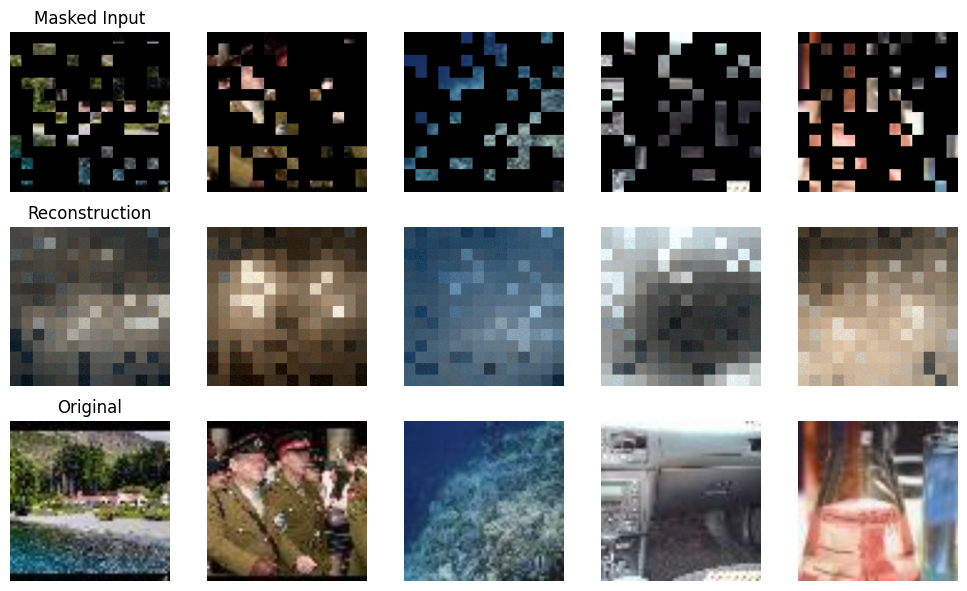

In [78]:
masked, recon = reconstruct_images(model, images)

show_reconstruction(images, masked, recon)

## loss vs epoch reconstruction

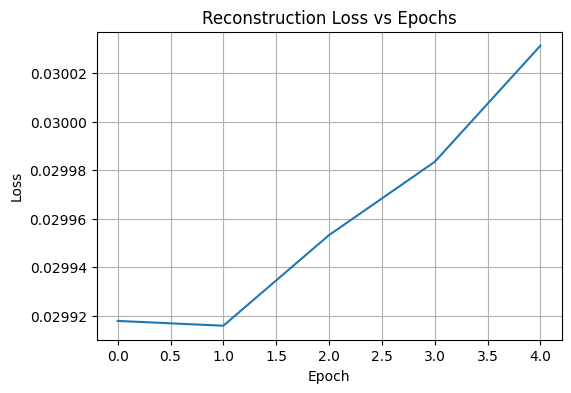

In [79]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Reconstruction Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

## PSNR metric

In [85]:
def compute_psnr(original, reconstructed):

    mse = torch.mean((original - reconstructed) ** 2)

    if mse == 0:
        return 100

    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))

    return psnr.item()

## SSIM metric

In [87]:
!pip install torchmetrics --quiet

In [89]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def compute_ssim(original, reconstructed):

    return ssim_metric(reconstructed, original).item()

In [90]:
images, _ = next(iter(dataloader))
images = images[:5].to(device)

masked, recon = reconstruct_images(model, images)

psnr_score = compute_psnr(images, recon)
ssim_score = compute_ssim(images, recon)

print("PSNR:", psnr_score)
print("SSIM:", ssim_score)

PSNR: 16.358478546142578
SSIM: 0.371293842792511


In [91]:
def mae_reconstruct(image, mask_ratio):

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        patches = patchify(img)

        x = model.patch_embed(patches)

        x = x + model.pos_embed

        # apply custom masking ratio
        x_visible, mask, ids_restore = random_masking(x, mask_ratio)

        latent = model.encoder(x_visible)

        x = model.enc_to_dec(latent)

        B, N, D = x.shape

        mask_tokens = model.mask_token.repeat(
            B,
            NUM_PATCHES - N,
            1
        )

        x_ = torch.cat([x, mask_tokens], dim=1)

        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1,1,D)
        )

        x_ = x_ + model.decoder_pos_embed

        x_ = model.decoder(x_)

        pred = model.head(x_)

        recon = unpatchify(pred)

    recon = recon[0].permute(1,2,0).cpu().numpy()

    return recon

## Gradio interface

In [98]:
import gradio as gr

interface = gr.Interface(
    fn=mae_reconstruct,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(
            minimum=0.5,
            maximum=0.9,
            value=0.75,
            step=0.05,
            label="Masking Ratio"
        )
    ],
    outputs=gr.Image(label="Reconstructed Image"),
    title="Masked Autoencoder Image Reconstruction",
    description="Upload an image and adjust masking ratio to see MAE reconstruction."
)

interface.launch(
    share=False,
    inline=True
)""

* Running on local URL:  http://127.0.0.1:7862
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).


Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


In [99]:
""

''